In [ ]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.8 MB/s eta 0:00:00


In [ ]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://aflow.org/API/aflux/"  # placeholder

SELECT = ",".join([
    "compound",
    "auid",
    "positions_fractional",
    "lattice_vectors",
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
    "agl_thermal_conductivity_300K",
])

PER_PAGE = 500
MAX_PAGES = 2000

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]



In [ ]:

KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [ ]:
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "ael_debye_temperature(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cp_300K(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "agl_vibrational_entropy_300K_atom(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 1000
MAX_PAGES = 10   # safety cap: 300k entries max; adjust if needed

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [ ]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [ ]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [ ]:
df = fetch_all_aflow()


Paging AFLOW:  60%|██████    | 6/10 [00:08<00:05,  1.36s/it]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),ael_debye_temperature(*),agl_debye(*),agl_acoustic_debye(*),agl_gruneisen(*),agl_heat_capacity_Cp_300K(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),agl_vibrational_entropy_300K_atom(*),positions_fractional(*),geometry(*),$format(json),$paging(7,1000)


In [ ]:
# ============================================================
# 3) Extra imports + config
# ============================================================
import copy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from typing import List, Optional
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool

TARGET_KEY = "agl_thermal_conductivity_300K"
POS_KEY = "positions_fractional"
LAT_KEY = "lattice_vectors"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_acoustic_debye",
    "spacegroup_relax",
]

POSITION_KEYS = ["positions_fractional", "positions_cartesian"]
LATTICE_KEYS = ["lattice_vectors", "lattice"]
SPECIES_KEYS = ["species", "species_pp", "species_names"]

TEST_RATIO = 0.1
VAL_RATIO = 0.1
WEIGHT_DECAY = 1e-4
MODEL_SAVE_PATH = "best_model.pt"

In [ ]:
# ============================================================
# 4) Periodic table + chemistry helpers
# ============================================================
PERIODIC_TABLE = {
    "H": (1, 1.008), "He": (2, 4.0026),
    "Li": (3, 6.94), "Be": (4, 9.0122), "B": (5, 10.81), "C": (6, 12.011),
    "N": (7, 14.007), "O": (8, 15.999), "F": (9, 18.998), "Ne": (10, 20.180),
    "Na": (11, 22.990), "Mg": (12, 24.305), "Al": (13, 26.982), "Si": (14, 28.085),
    "P": (15, 30.974), "S": (16, 32.06), "Cl": (17, 35.45), "Ar": (18, 39.948),
    "K": (19, 39.098), "Ca": (20, 40.078), "Sc": (21, 44.956), "Ti": (22, 47.867),
    "V": (23, 50.942), "Cr": (24, 51.996), "Mn": (25, 54.938), "Fe": (26, 55.845),
    "Co": (27, 58.933), "Ni": (28, 58.693), "Cu": (29, 63.546), "Zn": (30, 65.38),
    "Ga": (31, 69.723), "Ge": (32, 72.630), "As": (33, 74.922), "Se": (34, 78.971),
    "Br": (35, 79.904), "Kr": (36, 83.798), "Rb": (37, 85.468), "Sr": (38, 87.62),
    "Y": (39, 88.906), "Zr": (40, 91.224), "Nb": (41, 92.906), "Mo": (42, 95.95),
    "Tc": (43, 98.0), "Ru": (44, 101.07), "Rh": (45, 102.91), "Pd": (46, 106.42),
    "Ag": (47, 107.8682), "Cd": (48, 112.414), "In": (49, 114.818), "Sn": (50, 118.71),
    "Sb": (51, 121.76), "Te": (52, 127.60), "I": (53, 126.904), "Xe": (54, 131.293),
    "Cs": (55, 132.905), "Ba": (56, 137.327), "La": (57, 138.905), "Ce": (58, 140.116),
    "Pr": (59, 140.908), "Nd": (60, 144.242), "Pm": (61, 145.0), "Sm": (62, 150.36),
    "Eu": (63, 151.964), "Gd": (64, 157.25), "Tb": (65, 158.925), "Dy": (66, 162.50),
    "Ho": (67, 164.930), "Er": (68, 167.259), "Tm": (69, 168.934), "Yb": (70, 173.045),
    "Lu": (71, 174.967), "Hf": (72, 178.49), "Ta": (73, 180.948), "W": (74, 183.84),
    "Re": (75, 186.207), "Os": (76, 190.23), "Ir": (77, 192.217), "Pt": (78, 195.084),
    "Au": (79, 196.967), "Hg": (80, 200.592), "Tl": (81, 204.38), "Pb": (82, 207.2),
    "Bi": (83, 208.980), "Po": (84, 209.0), "At": (85, 210.0), "Rn": (86, 222.0)
}

def parse_formula(formula: str):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", str(formula))
    counts = {}
    expanded = []
    for sym, num in tokens:
        n = int(num) if num else 1
        counts[sym] = counts.get(sym, 0) + n
        expanded.extend([sym] * n)
    return expanded, counts

def assign_masses(compound: str):
    elems, _ = parse_formula(compound)
    masses, Zs = [], []
    for sym in elems:
        if sym not in PERIODIC_TABLE:
            raise KeyError(f"Unknown element in formula: {sym}")
        Z, m = PERIODIC_TABLE[sym]
        Zs.append(int(Z))
        masses.append(float(m))
    return masses, Zs

In [ ]:
# ============================================================
# 5) Graph building helpers
# ============================================================
def _first_existing_key(entry: dict, keys: List[str]) -> Optional[str]:
    for k in keys:
        if k in entry and entry[k] is not None:
            return k
    return None

def _wrap_frac_delta(df_: np.ndarray):
    return df_ - np.round(df_)

def _coerce_lattice(obj):
    if obj is None:
        return None
    arr = np.array(obj, dtype=float)
    if arr.shape == (3, 3):
        return arr
    if arr.size == 9:
        return arr.reshape(3, 3)
    return None

def pbc_distances(frac: np.ndarray, lattice: Optional[np.ndarray]):
    frac = np.asarray(frac, dtype=float)
    df_ = frac[None, :, :] - frac[:, None, :]
    df_ = _wrap_frac_delta(df_)
    dvec = df_ if lattice is None else (df_ @ np.asarray(lattice, dtype=float))
    return np.linalg.norm(dvec, axis=-1)

def assign_edges(positions_fractional: np.ndarray, lattice: Optional[np.ndarray], k: int = 12):
    frac = np.asarray(positions_fractional, dtype=float)
    N = frac.shape[0]
    D = pbc_distances(frac, lattice)

    srcs, dsts, dists = [], [], []
    for i in range(N):
        idx = np.argsort(D[i])
        idx = idx[idx != i]
        for j in idx[:min(k, len(idx))]:
            srcs.append(i)
            dsts.append(int(j))
            dists.append(float(D[i, j]))

    edge_index = torch.tensor([srcs, dsts], dtype=torch.long)
    dist_arr = np.array(dists, dtype=float)
    return edge_index, dist_arr

def assign_global_attributes(entry: dict, keys: List[str]):
    vals = []
    for k in keys:
        v = entry.get(k, np.nan)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            v = 0.0
        vals.append(float(v))
    return torch.tensor(vals, dtype=torch.float32).view(1, -1)

In [ ]:
# ============================================================
# 6) Build graph from AFLOW entry
# ============================================================
def build_graph_from_entry(entry: dict, k: int = 12):
    pos_key = _first_existing_key(entry, POSITION_KEYS)
    if pos_key is None:
        raise KeyError(f"No positions key found. Tried {POSITION_KEYS}")

    frac = np.array(entry[pos_key], dtype=float)
    if frac.ndim != 2 or frac.shape[1] != 3:
        raise ValueError(f"Positions {pos_key} has invalid shape: {frac.shape}")

    lat_key = _first_existing_key(entry, LATTICE_KEYS)
    lattice = _coerce_lattice(entry.get(lat_key)) if lat_key else None

    species_key = _first_existing_key(entry, SPECIES_KEYS)

    if species_key is not None:
        species = list(entry[species_key])
        Zs, masses = [], []
        for s in species:
            if s not in PERIODIC_TABLE:
                raise KeyError(f"Unknown species: {s}")
            Z, m = PERIODIC_TABLE[s]
            Zs.append(float(Z))
            masses.append(float(m))
    else:
        masses, Zs = assign_masses(entry["compound"])

    n_sites = len(frac)
    if len(Zs) != n_sites:
        if len(Zs) < n_sites:
            reps = int(np.ceil(n_sites / len(Zs)))
            Zs = (Zs * reps)[:n_sites]
            masses = (masses * reps)[:n_sites]
        else:
            Zs = Zs[:n_sites]
            masses = masses[:n_sites]

    x = torch.tensor(np.stack([Zs, masses], axis=1), dtype=torch.float32)

    edge_index, dist_arr = assign_edges(frac, lattice, k=k)
    inv_d = 1.0 / (dist_arr + EDGE_EPS)
    edge_attr = torch.tensor(np.stack([dist_arr, inv_d], axis=1), dtype=torch.float32)

    u = assign_global_attributes(entry, GLOBAL_FEATURE_KEYS)

    y_raw = float(entry[TARGET_KEY])
    y = torch.tensor([[np.log1p(y_raw)]], dtype=torch.float32)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        u=u,
        y=y
    )
    data.compound = str(entry.get("compound", "unknown"))
    data.auid = str(entry.get("auid", "unknown"))
    return data


def df_to_graphs(df: pd.DataFrame, k: int = 12, limit: Optional[int] = None):
    graphs, skipped = [], []
    n = len(df) if limit is None else min(len(df), limit)

    for i in tqdm(range(n), desc="Building graphs"):
        entry = df.iloc[i].to_dict()
        try:
            graphs.append(build_graph_from_entry(entry, k=k))
        except Exception as e:
            skipped.append((i, str(e)))

    print(f"Built graphs: {len(graphs)} / {n}, skipped: {len(skipped)}")
    return graphs, skipped

In [ ]:
# ============================================================
# Convert dataframe to graphs
# ============================================================

from tqdm import tqdm

def df_to_graphs(df,k=12):

    graphs=[]

    for i in tqdm(range(len(df))):

        entry=df.iloc[i].to_dict()

        try:

            g=build_graph_from_entry(entry,k)

            graphs.append(g)

        except:

            pass

    print("graphs built:",len(graphs))

    return graphs

In [ ]:
graphs = df_to_graphs(df)

100%|██████████| 5553/5553 [00:04<00:00, 1156.11it/s]

graphs built: 5320


In [ ]:
# ============================================================
# Split dataset
# ============================================================

idx=list(range(len(graphs)))

random.shuffle(idx)

n=len(idx)

n_test=int(n*TEST_RATIO)

n_val=int(n*VAL_RATIO)

train=[graphs[i] for i in idx[:n-n_val-n_test]]
val=[graphs[i] for i in idx[n-n_val-n_test:n-n_test]]
test=[graphs[i] for i in idx[n-n_test:]]

print(len(train),len(val),len(test))

4256 532 532


In [ ]:
# ============================================================
# GNN model
# ============================================================

class EdgeMP(MessagePassing):

    def __init__(self,x_dim,e_dim,hidden):

        super().__init__(aggr="add")

        self.msg = nn.Sequential(
            nn.Linear(x_dim+e_dim,hidden),
            nn.ReLU(),
            nn.Linear(hidden,hidden),
            nn.ReLU()
        )

        self.upd = nn.Sequential(
            nn.Linear(x_dim+hidden,hidden),
            nn.ReLU(),
            nn.Linear(hidden,hidden),
            nn.ReLU()
        )

        self.res = nn.Linear(x_dim,hidden)


    def forward(self,x,edge_index,edge_attr):

        m=self.propagate(edge_index,x=x,edge_attr=edge_attr)

        out=self.upd(torch.cat([x,m],dim=-1))

        return out+self.res(x)


    def message(self,x_j,edge_attr):

        return self.msg(torch.cat([x_j,edge_attr],dim=-1))


class GraphRegressor(nn.Module):

    def __init__(self,x_dim,e_dim,u_dim,hidden=128,depth=3):

        super().__init__()

        self.layers=nn.ModuleList([
            EdgeMP(x_dim if i==0 else hidden,e_dim,hidden)
            for i in range(depth)
        ])

        self.head=nn.Sequential(

            nn.Linear(hidden+u_dim,hidden),

            nn.ReLU(),

            nn.Linear(hidden,hidden//2),

            nn.ReLU(),

            nn.Linear(hidden//2,1)

        )


    def forward(self,data):

        x=data.x

        edge_index=data.edge_index

        edge_attr=data.edge_attr

        batch=data.batch

        u=data.u

        for l in self.layers:

            x=l(x,edge_index,edge_attr)

        g=global_mean_pool(x,batch)

        return self.head(torch.cat([g,u],dim=-1))

In [ ]:
def train_model(train,val,epochs=10,batch_size=32,lr=1e-3):

    train_loader=DataLoader(train,batch_size=batch_size,shuffle=True)
    val_loader=DataLoader(val,batch_size=batch_size)

    g0=train[0]

    model=GraphRegressor(
        g0.x.size(-1),
        g0.edge_attr.size(-1),
        g0.u.size(-1)
    ).to(device)

    opt=torch.optim.Adam(model.parameters(),lr=lr)

    loss_fn=nn.MSELoss()

    history={"train":[],"val":[]}

    best=1e9

    for epoch in range(epochs):

        model.train()

        tot=0

        for batch in train_loader:

            batch=batch.to(device)

            opt.zero_grad()

            pred=model(batch).view(-1)

            y=batch.y.view(-1)

            loss=loss_fn(pred,y)

            loss.backward()

            opt.step()

            tot+=loss.item()

        train_loss=tot/len(train_loader)

        model.eval()

        tot=0

        with torch.no_grad():

            for batch in val_loader:

                batch=batch.to(device)

                pred=model(batch).view(-1)

                y=batch.y.view(-1)

                tot+=loss_fn(pred,y).item()

        val_loss=tot/len(val_loader)

        history["train"].append(train_loss)

        history["val"].append(val_loss)

        print(epoch,train_loss,val_loss)

        if val_loss<best:

            best=val_loss

            torch.save(model.state_dict(),MODEL_SAVE_PATH)

    return model,history

In [ ]:
model,history = train_model(train,val)

0 0.9962794010604459 0.0730244385845521
1 0.07840238706229773 0.05672786275253577
2 0.09066016161184114 0.06295951970798128
3 0.07169499575979728 0.06026782117345754
4 0.0727649734432536 0.06453558232854395
5 0.08204663018310877 0.13498318545958576
6 0.270509234342472 0.07406172528862953
7 0.06579563917970299 0.051453707520576084
8 0.05984796544438914 0.04622891950694954
9 0.05755112800551088 0.0699225065900999


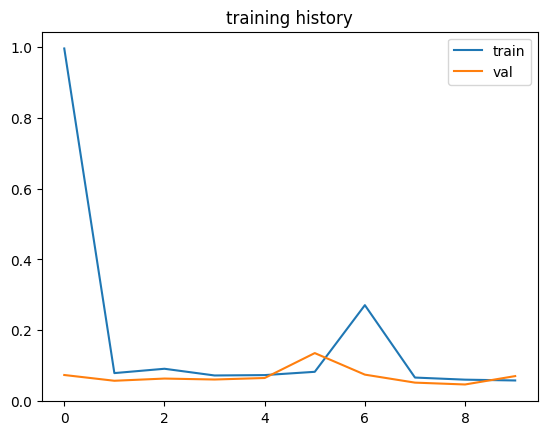

In [ ]:
plt.plot(history["train"],label="train")
plt.plot(history["val"],label="val")
plt.legend()
plt.title("training history")
plt.show()

In [ ]:
test_loader=DataLoader(test,batch_size=32)

model.load_state_dict(torch.load(MODEL_SAVE_PATH))

model.eval()

true=[]
pred=[]

with torch.no_grad():

    for batch in test_loader:

        batch=batch.to(device)

        p=model(batch).view(-1).cpu().numpy()

        y=batch.y.view(-1).cpu().numpy()

        true.append(y)
        pred.append(p)

true=np.concatenate(true)
pred=np.concatenate(pred)

print("MAE",mean_absolute_error(true,pred))
print("R2",r2_score(true,pred))

MAE 0.1667248010635376
R2 0.9266224503517151


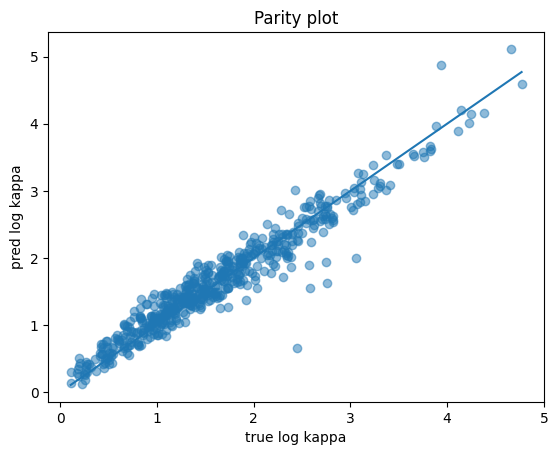

In [ ]:
plt.scatter(true,pred,alpha=0.5)

plt.plot([true.min(),true.max()],
         [true.min(),true.max()])

plt.xlabel("true log kappa")

plt.ylabel("pred log kappa")

plt.title("Parity plot")

plt.show()